In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv("../dataset/clean/customers.csv")
orders = pd.read_csv("../dataset/clean/orders.csv")
payments = pd.read_csv("../dataset/clean/payments.csv")
reviews = pd.read_csv("../dataset/clean/reviews.csv")
products = pd.read_csv("../dataset/clean/products.csv")
items = pd.read_csv("../dataset/clean/items.csv")
category = pd.read_csv("../dataset/clean/category.csv")

In [2]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

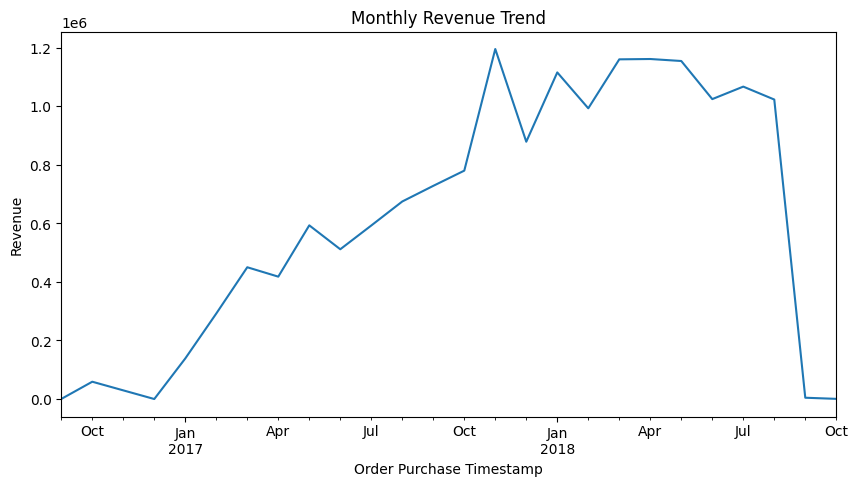

In [5]:
revenue = (
    orders[['order_id', 'order_purchase_timestamp']]
    .merge(payments, on='order_id')
)

monthly_revenue = (
    revenue
    .groupby(revenue['order_purchase_timestamp'].dt.to_period('M'))
    ['payment_value']
    .sum()
)

monthly_revenue.plot(figsize=(10,5))
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xlabel('Order Purchase Timestamp')
plt.show()

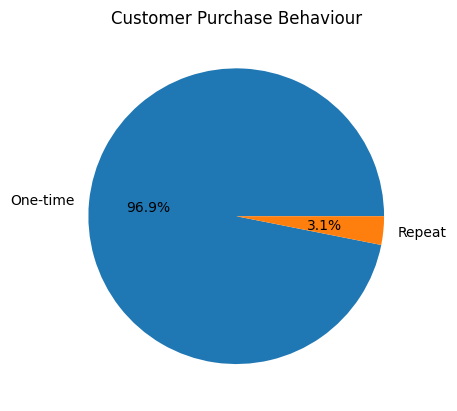

In [6]:
cust_orders = (
    customers[['customer_id','customer_unique_id']]
    .merge(orders[['order_id','customer_id']], on='customer_id')
)

counts = cust_orders.groupby('customer_unique_id')['order_id'].nunique()

repeat = (counts > 1).sum()
one_time = (counts == 1).sum()

plt.pie(
    [one_time, repeat],
    labels=['One-time','Repeat'],
    autopct='%1.1f%%'
)
plt.title('Customer Purchase Behaviour')
plt.show()

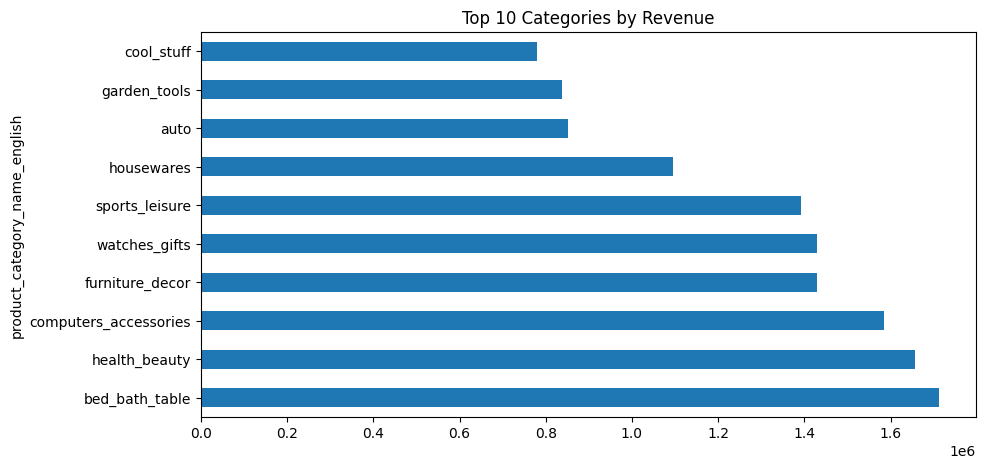

In [7]:
cat_rev = (
    items[['order_id','product_id']]
    .merge(products[['product_id','product_category_name']], on='product_id')
    .merge(category, on='product_category_name')
    .merge(payments[['order_id','payment_value']], on='order_id')
)

top_cat = (
    cat_rev.groupby('product_category_name_english')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_cat.plot(kind='barh', figsize=(10,5))
plt.title('Top 10 Categories by Revenue')
plt.show()

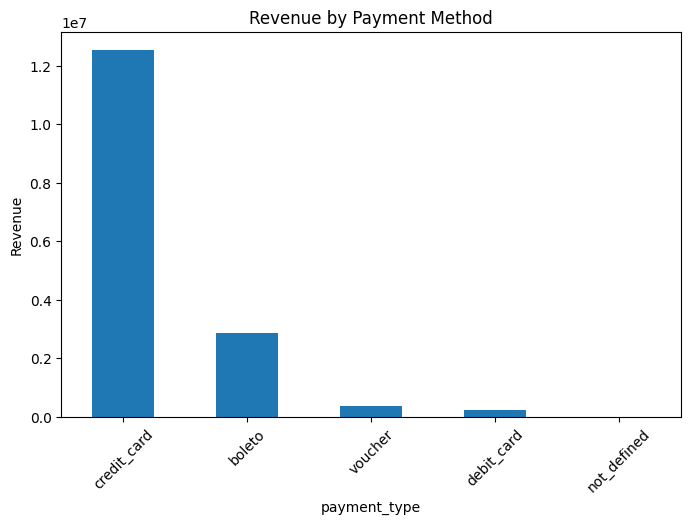

In [8]:
payment_summary = payments.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

payment_summary.plot(kind='bar', figsize=(8,5))
plt.title('Revenue by Payment Method')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

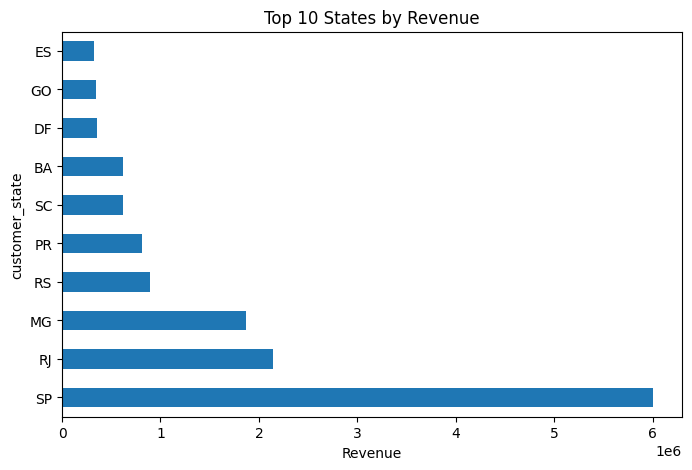

In [9]:
state_rev = (
    customers[['customer_id','customer_state']]
    .merge(orders[['order_id','customer_id']], on='customer_id')
    .merge(payments[['order_id','payment_value']], on='order_id')
)

top_states = (
    state_rev.groupby('customer_state')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states.plot(kind='barh', figsize=(8,5))
plt.title('Top 10 States by Revenue')
plt.xlabel('Revenue')
plt.show()

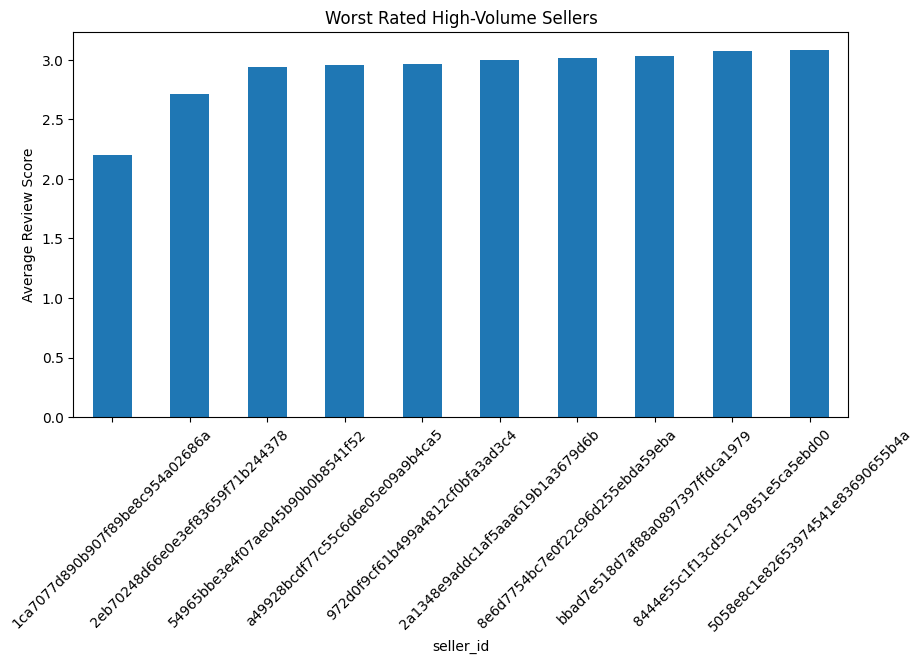

In [10]:
seller_reviews = (
    items[['order_id','seller_id']]
    .merge(reviews[['order_id','review_score']], on='order_id')
)

worst_sellers = (
    seller_reviews.groupby('seller_id')
    .agg(avg_rating=('review_score','mean'),
         orders=('order_id','nunique'))
)

worst_sellers = (
    worst_sellers[worst_sellers['orders'] >= 50]
    .sort_values('avg_rating')
    .head(10)
)

worst_sellers['avg_rating'].plot(kind='bar', figsize=(10,5))
plt.title('Worst Rated High-Volume Sellers')
plt.ylabel('Average Review Score')
plt.xticks(rotation=45)
plt.show()